
# Credit Risk Default Prediction: A Cost-Sensitive Business Approach

## 1. Business Context
In credit risk modeling, the traditional approach of optimizing for standard metrics like accuracy and using a default decision threshold of 0.5 often fails to capture the true business impact. 

For a retail bank, the cost of making a mistake is highly asymmetric:
- **Cost of a False Negative (FN)**: Missing a default costs **Â£25,000** (principal write-off, collections).
- **Cost of a False Positive (FP)**: Wrongly rejecting a good customer costs **Â£2,500** (lost lifetime value).

This creates a **10:1 cost ratio**. Missing a default is 10 times worse than a false alarm. 
This notebook builds an end-to-end ML pipeline that optimizes the decision threshold directly for minimum business cost.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import optuna
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
# Ensure outputs directory exists
import os
os.makedirs('../outputs/figures', exist_ok=True)


D:\PhD\Model_learning\new_learning\project_4_business_ml\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Data Loading
We fetch the **Default of Credit Card Clients** dataset (UCI ID 350) containing 30,000 samples and 23 features.


In [2]:

# Fetch dataset
dataset = fetch_ucirepo(id=350)
X_raw = dataset.data.features.copy()
y = dataset.data.targets.copy()

# Fix column names since ucimlrepo returns X1-X23
feature_names = {
    'X1': 'LIMIT_BAL', 'X2': 'SEX', 'X3': 'EDUCATION', 'X4': 'MARRIAGE', 'X5': 'AGE',
    'X6': 'PAY_0', 'X7': 'PAY_2', 'X8': 'PAY_3', 'X9': 'PAY_4', 'X10': 'PAY_5', 'X11': 'PAY_6',
    'X12': 'BILL_AMT1', 'X13': 'BILL_AMT2', 'X14': 'BILL_AMT3', 'X15': 'BILL_AMT4', 'X16': 'BILL_AMT5', 'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1', 'X19': 'PAY_AMT2', 'X20': 'PAY_AMT3', 'X21': 'PAY_AMT4', 'X22': 'PAY_AMT5', 'X23': 'PAY_AMT6'
}
X_raw.rename(columns=feature_names, inplace=True)

# Fix target name
y.columns = ['default']

# Display basic info
print(f"Data shape: {X_raw.shape}")
display(X_raw.head())


Data shape: (30000, 23)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679



## 3. Exploratory Data Analysis (EDA)
Understanding the class imbalance and feature distributions.


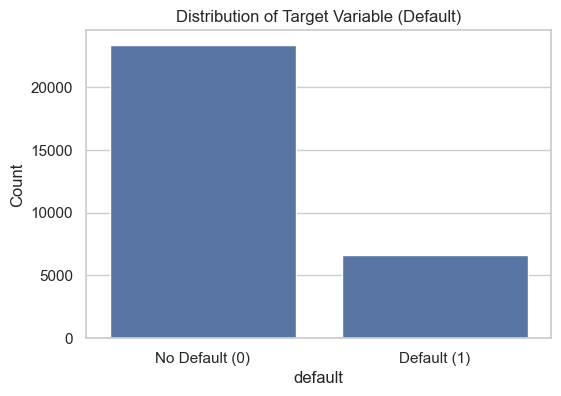

Base Default Rate: 22.12%


In [3]:

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=y)
plt.title('Distribution of Target Variable (Default)')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/target_dist.png', bbox_inches='tight')
plt.show()

default_rate = y['default'].mean()
print(f"Base Default Rate: {default_rate:.2%}")



## 4. Preprocessing & Feature Engineering
We clean undocumented categories and engineer business-relevant features to capture payment behavior trends.


In [4]:

def engineer_features(X_df):
    X = X_df.copy()
    
    # 1. Clean categories (Education 5,6,0 -> 4, Marriage 0 -> 3)
    X['EDUCATION'] = X['EDUCATION'].replace([0, 5, 6], 4)
    X['MARRIAGE'] = X['MARRIAGE'].replace(0, 3)
    
    # Rename PAY_0 to PAY_1 for consistency
    if 'PAY_0' in X.columns:
        X.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)
        
    pay_status_cols = [f'PAY_{i}' for i in range(1, 7)]
    bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
    
    # 2. Utilization Features
    X['utilization_rate'] = X['BILL_AMT1'] / (X['LIMIT_BAL'] + 1e-5)
    X['avg_utilization'] = X[bill_cols].mean(axis=1) / (X['LIMIT_BAL'] + 1e-5)
    
    # 3. Payment Behavior
    X['late_payment_count'] = (X[pay_status_cols] > 0).sum(axis=1)
    X['max_delay'] = X[pay_status_cols].max(axis=1)
    X['payment_trend'] = X['PAY_1'] - X['PAY_6']
    
    # 4. Financial trajectory
    X['total_bill'] = X[bill_cols].sum(axis=1)
    X['total_paid'] = X[pay_amt_cols].sum(axis=1)
    X['bill_pay_diff'] = X['total_bill'] - X['total_paid']
    
    return X

X = engineer_features(X_raw)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y['default'], test_size=0.2, random_state=42, stratify=y['default']
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Training set: 24000 samples
Testing set: 6000 samples



## 5. Model Training & Hyperparameter Tuning
We use `imblearn`'s SMOTE inside a cross-validation pipeline to handle class imbalance without data leakage. We optimize an XGBoost classifier using Optuna.


In [5]:

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'auc',
        'n_jobs': -1
    }
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # Pipeline with SMOTE
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('xgb', xgb.XGBClassifier(**params))
        ])
        
        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(auc_scores)

# Run Optuna Study
study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppress output
study.optimize(objective, n_trials=30)

print(f"Best CV AUC: {study.best_value:.4f}")
print("Best Params:", study.best_params)

# Train Final Model
best_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(**study.best_params, random_state=42, n_jobs=-1, eval_metric='auc'))
])

best_pipeline.fit(X_train, y_train)

# Evaluate Baseline
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("\nBaseline Evaluation (Threshold 0.5):")
print(f"Test AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred_default))


[I 2026-06-01 21:04:42,069] A new study created in memory with name: no-name-2eab57bd-788a-4c7c-85a7-b76dce3980bb


Best CV AUC: 0.7677
Best Params: {'n_estimators': 145, 'max_depth': 6, 'learning_rate': 0.010545321184591299, 'subsample': 0.6532732114085856, 'colsample_bytree': 0.7923040787402166, 'min_child_weight': 2}



Baseline Evaluation (Threshold 0.5):
Test AUC: 0.7594
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.46      0.56      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.67      6000
weighted avg       0.78      0.76      0.77      6000




## 6. Threshold Optimization (Cost-Sensitive)
This is the core business logic. We evaluate thresholds from 0.01 to 0.99 to find the point that minimizes the total business cost based on our Cost Matrix.


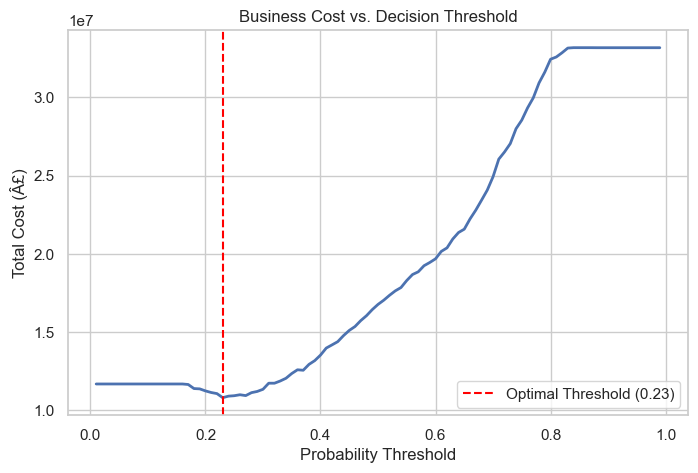

Optimal Threshold: 0.23
Cost at 0.5 Threshold: Â£16,767,500.00
Cost at Optimal Threshold: Â£10,807,500.00
Total Savings on Test Set: Â£5,960,000.00


In [6]:

COST_FN = 25000  # Cost of missing a default (Â£25,000)
COST_FP = 2500   # Cost of wrongly flagging a good customer (Â£2,500)

thresholds = np.linspace(0.01, 0.99, 99)
costs = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    fn = cm[1, 0]
    fp = cm[0, 1]
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append(total_cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = costs[optimal_idx]

# Plot Cost Curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, lw=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.title('Business Cost vs. Decision Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Cost (Â£)')
plt.legend()
plt.savefig('../outputs/figures/cost_curve.png', bbox_inches='tight')
plt.show()

# Savings calculation
cost_at_05 = costs[np.argmin(np.abs(thresholds - 0.5))]
savings = cost_at_05 - min_cost

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Cost at 0.5 Threshold: Â£{cost_at_05:,.2f}")
print(f"Cost at Optimal Threshold: Â£{min_cost:,.2f}")
print(f"Total Savings on Test Set: Â£{savings:,.2f}")


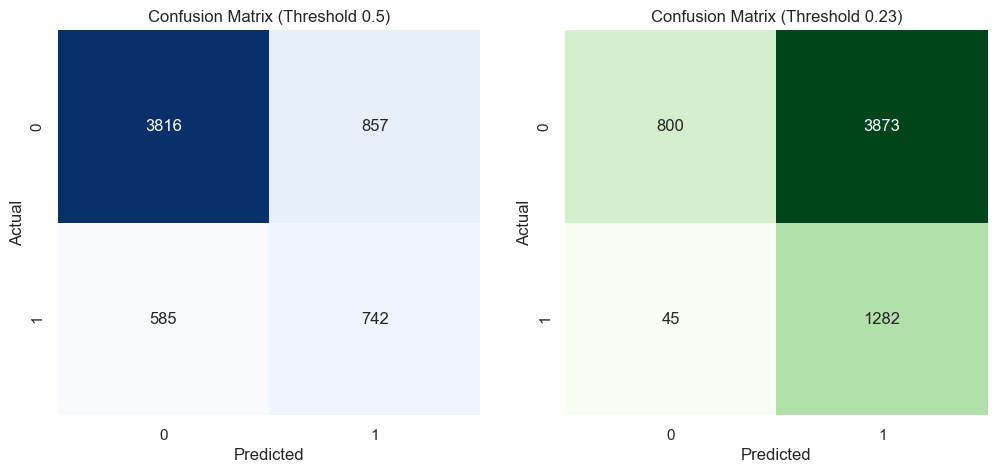

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, (y_proba >= 0.5).astype(int))
cm_optimal = confusion_matrix(y_test, (y_proba >= optimal_threshold).astype(int))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (Threshold 0.5)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f'Confusion Matrix (Threshold {optimal_threshold:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.savefig('../outputs/figures/confusion_matrices.png', bbox_inches='tight')
plt.show()



## 7. Model Interpretability (SHAP)
Explainability is crucial for regulatory compliance and trust. We use SHAP values to identify global risk factors and explain individual predictions.


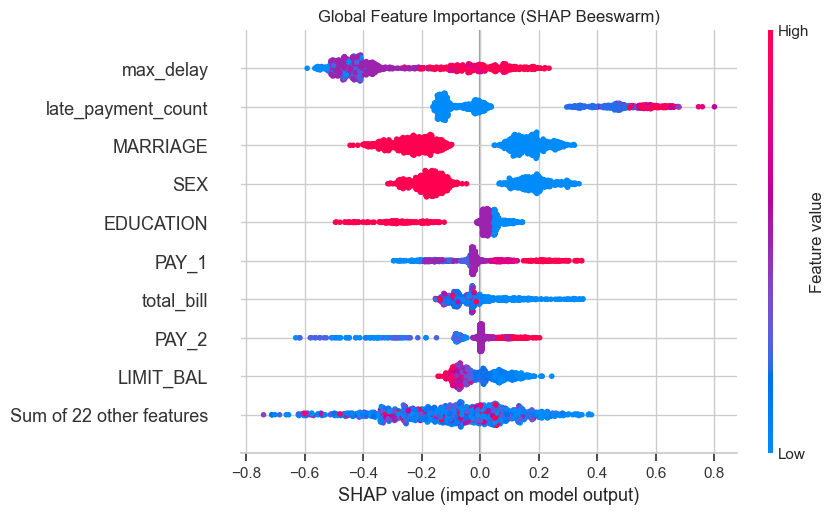

In [8]:

xgb_model = best_pipeline.named_steps['xgb']
explainer = shap.TreeExplainer(xgb_model)
# Calculate SHAP values for a subset to save time
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer(X_test_sample)

# Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title('Global Feature Importance (SHAP Beeswarm)')
plt.savefig('../outputs/figures/shap_beeswarm.png', bbox_inches='tight')
plt.show()


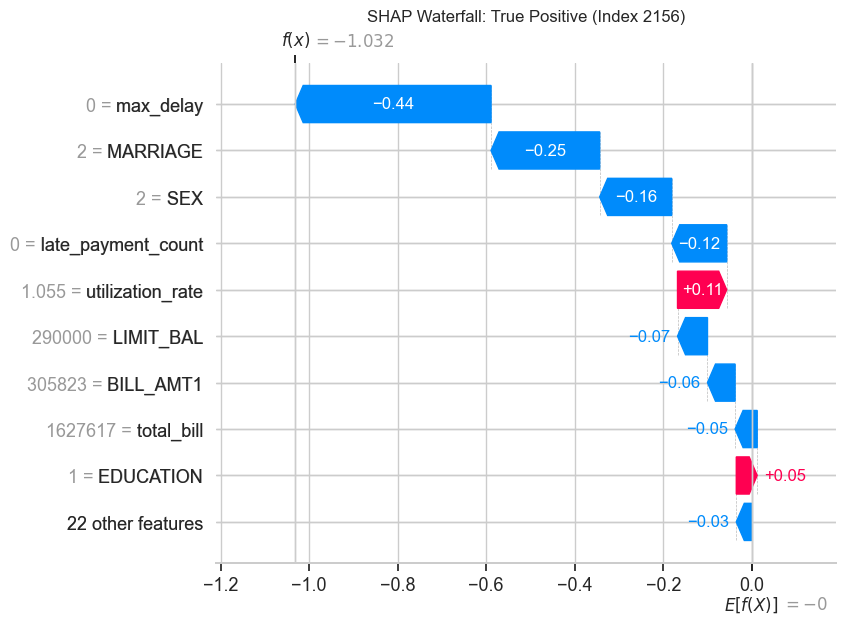

In [9]:

# Waterfall plot for a True Positive (Correctly identified default)
preds_optimal = (y_proba >= optimal_threshold).astype(int)
tp_indices = np.where((y_test == 1) & (preds_optimal == 1))[0]

if len(tp_indices) > 0:
    tp_idx = tp_indices[0]
    sample_idx = X_test.index[tp_idx]
    # We must pass the raw features through SHAP explainer
    shap_val_single = explainer(X_test.loc[[sample_idx]])
    
    plt.figure()
    shap.plots.waterfall(shap_val_single[0], show=False)
    plt.title(f'SHAP Waterfall: True Positive (Index {sample_idx})')
    plt.savefig('../outputs/figures/shap_waterfall_tp.png', bbox_inches='tight')
    plt.show()



## 8. Business Impact Summary


In [10]:

tp_opt = cm_optimal[1, 1]
tp_def = cm_default[1, 1]
additional_defaults_caught = tp_opt - tp_def
percent_increase = (additional_defaults_caught / tp_def) * 100 if tp_def > 0 else 0

print(f"By shifting the decision threshold from 0.50 to {optimal_threshold:.2f}:")
print(f"- We catch {additional_defaults_caught} additional defaults in the test set ({percent_increase:.1f}% increase).")
print(f"- We save the bank Â£{savings:,.2f} in preventable losses, even after accounting for the Â£2,500 cost of wrongly flagging some good customers.")


By shifting the decision threshold from 0.50 to 0.23:
- We catch 540 additional defaults in the test set (72.8% increase).
- We save the bank Â£5,960,000.00 in preventable losses, even after accounting for the Â£2,500 cost of wrongly flagging some good customers.
